Training documents: 11314
Testing documents: 7532
Number of classes: 20

Multinomial Naive Bayes
Accuracy: 0.6511
F1-Score: 0.6296

Bernoulli Naive Bayes
Accuracy: 0.4851
F1-Score: 0.4808

Comparison
                  Model  Accuracy  F1-Score
Multinomial Naive Bayes  0.651089  0.629644
  Bernoulli Naive Bayes  0.485130  0.480839


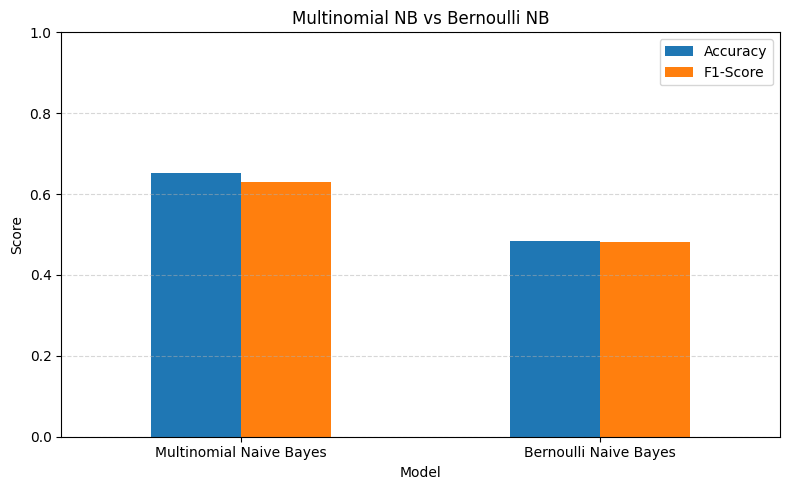


Multinomial Naive Bayes performed better.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, f1_score

# Load the 20 Newsgroups dataset
train_data = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

test_data = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes')
)

X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

print("Training documents:", len(X_train_text))
print("Testing documents:", len(X_test_text))
print("Number of classes:", len(train_data.target_names))


# Multinomial Naive Bayes

vectorizer_mnb = CountVectorizer(
    stop_words='english',
    min_df=2,
    max_df=0.95
)

X_train_mnb = vectorizer_mnb.fit_transform(X_train_text)
X_test_mnb = vectorizer_mnb.transform(X_test_text)

mnb = MultinomialNB()
mnb.fit(X_train_mnb, y_train)

y_pred_mnb = mnb.predict(X_test_mnb)

mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_f1 = f1_score(y_test, y_pred_mnb, average='weighted')

print("\nMultinomial Naive Bayes")
print("Accuracy:", round(mnb_accuracy, 4))
print("F1-Score:", round(mnb_f1, 4))


# Bernoulli Naive Bayes

vectorizer_bnb = CountVectorizer(
    stop_words='english',
    binary=True,
    min_df=2,
    max_df=0.95
)

X_train_bnb = vectorizer_bnb.fit_transform(X_train_text)
X_test_bnb = vectorizer_bnb.transform(X_test_text)

bnb = BernoulliNB()
bnb.fit(X_train_bnb, y_train)

y_pred_bnb = bnb.predict(X_test_bnb)

bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_f1 = f1_score(y_test, y_pred_bnb, average='weighted')

print("\nBernoulli Naive Bayes")
print("Accuracy:", round(bnb_accuracy, 4))
print("F1-Score:", round(bnb_f1, 4))


# Comparison

results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Bernoulli Naive Bayes'
    ],
    'Accuracy': [
        mnb_accuracy,
        bnb_accuracy
    ],
    'F1-Score': [
        mnb_f1,
        bnb_f1
    ]
})

print("\nComparison")
print(results.to_string(index=False))


# Plot Accuracy and F1-Score

results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Multinomial NB vs Bernoulli NB")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Find the better model

if mnb_f1 > bnb_f1:
    print("\nMultinomial Naive Bayes performed better.")
elif bnb_f1 > mnb_f1:
    print("\nBernoulli Naive Bayes performed better.")
else:
    print("\nBoth models have the same F1-Score.")